# Bird Call Dataset Classifier

- Currently supports only 5 classes ['bewickii', 'cardinalis', 'melodia', 'migratorius', 'polyglottos']

In [ ]:
# Mount this drive
!pip install torchinfo
!pip install wandb
!pip install torchviz
!pip install torchview

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import torch
import torchvision
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import pathlib
from typing import List, Tuple, Dict
from torchvision import transforms
import os
from torch.utils.data import random_split
from PIL import Image
from torch import nn
from tqdm import tqdm
import torchvision.models as models
import logging
from torchinfo import summary
import wandb

torch.__version__,torch.cuda.is_available()

('2.5.1+cu124', True)

In [4]:
def find_classes(directory: str) -> Tuple[List[str],Dict[str,int]]:
  """
  Finds class names in a root directory and returns class tuple and class index dictionary
  """

  # Get classes using os.scandir
  classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

  if not classes:
    raise FileNotFoundError(f"Couldn't find any classes in {directory}")

  # Generate indexes for the class name
  class_to_idx = {class_name:i for i,class_name in enumerate(classes)}
  return classes,class_to_idx


In [6]:
class BirdCallDataset(Dataset):
    """Dataset for experimenting with CNNs on bird call spectrograms."""

    def __init__(self, root_dir: Path, transform: transforms = None, n_explore: int = 2):
        if n_explore <= 0 or n_explore > 5:
            raise ValueError("Invalid n_explore value. Must be between 1 and 5.")

        # Find all classes
        classes, class_to_idx = find_classes(root_dir)  # ignore the original class_to_idx

        # Take first n_explore classes
        self.classes = classes[:n_explore]

        # Create class_to_idx starting from 0
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        self.paths = []
        self.transform = transform

        for cls in self.classes:
            class_paths = list((pathlib.Path(root_dir) / cls).glob('*.png'))
            self.paths.extend(class_paths)

    def __len__(self):
        """Returns total number of samples"""
        return len(self.paths)

    def load_image(self, index: int) -> Image.Image:
        """Opens an image via path and returns it"""
        image_path = self.paths[index]
        return Image.open(image_path).convert("RGB")  # ensures RGB mode

    def __getitem__(self, index) -> Tuple[torch.Tensor, int, str]:
        """Returns one sample of data and label"""
        img = self.load_image(index)
        class_name = self.paths[index].parent.name
        class_idx = self.class_to_idx[class_name]

        if self.transform:
            img = self.transform(img)

        return img, class_idx

## 2. AUGMENTATION
*`torchvision.transforms`*

In [ ]:
transform = transforms.Compose(
    [
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225]) # Image net mean and image net std
    ]
)

root_dir = Path("/content/drive/MyDrive/data_/data")

data_5_c = BirdCallDataset(root_dir=root_dir, transform=transform, n_explore=5)




# 5 Class classification model


In [33]:
data_5_c = BirdCallDataset(root_dir=root_dir, transform=transform, n_explore=5)

In [34]:
data_5_c.classes

['bewickii', 'cardinalis', 'melodia', 'migratorius', 'polyglottos']

In [35]:
# Hyperparameters

BATCH_SIZE = 32
LEARNING_RATE = 0.01
HIDDEN_UNITS = 10
EPOCHS = 30
PATIENCE = 5
DELTA = 0.001
NUM_WORKERS = os.cpu_count()

In [36]:
train_dataloader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORKERS)
test_dataloader = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS)

print(f"Train dataloader: {train_dataloader}, length: {len(train_dataloader)}")
print(f"Test dataloader: {test_dataloader}, length: {len(test_dataloader)}")

Train dataloader: <torch.utils.data.dataloader.DataLoader object at 0x77fba26409d0>, length: 50
Test dataloader: <torch.utils.data.dataloader.DataLoader object at 0x77fba2656150>, length: 13


In [48]:
class ModelBaseline5class(nn.Module):

  """ Tiny VGG architecture <https://poloclub.github.io/cnn-explainer/> """

  def __init__(self,input_shape : int, output_shape : int, hidden_units : int, debug_mode : bool = False):
    super().__init__()
    self.debug = debug_mode
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(
            in_channels = input_shape,
            out_channels = hidden_units, # Number of kernels we want in that conv2d
            kernel_size = 3, # 10 x 3 x 3 x 3
            stride = 1,
            padding = 0,
        ),

        nn.ReLU(),
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units, # 10
            kernel_size=3, # 10 x 3 x 3 x 10
            stride = 1,
            padding = 0,
        ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=1),
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(
            in_channels = hidden_units,
            out_channels = hidden_units,
            kernel_size = 3,
            stride = 1,
            padding = 0,
        ),

        nn.ReLU(),
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            stride = 1,
            padding = 0,
        ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=1),
    )

    self.conv_block_3 =  nn.Sequential(
        nn.Conv2d(
            in_channels = hidden_units,
            out_channels = hidden_units,
            kernel_size = 3,
            stride = 1,
            padding = 0,
        ),

        nn.ReLU(),
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            stride = 1,
            padding = 0,
        ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=1),
    )

    self.conv_block_4 =  nn.Sequential(
        nn.Conv2d(
            in_channels = hidden_units,
            out_channels = hidden_units,
            kernel_size = 3,
            stride = 1,
            padding = 0,
        ),

        nn.ReLU(),
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            stride = 1,
            padding = 0,
        ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=1),
    )


    self.linear_block = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*204*204,out_features=output_shape)
    )

  def forward(self,x):
    print(f"Input shape: {x.shape} entering conv_block_1") if self.debug else None
    x = self.conv_block_1(x)
    print(f"Exited from conv_block_1 with output shape: {x.shape}") if self.debug else None
    print(f"Input shape: {x.shape} entering conv_block_2") if self.debug else None
    x = self.conv_block_2(x)
    print(f"Exited from conv_block_2 with output shape: {x.shape}")  if self.debug else None
    print(f"Input shape: {x.shape} entering conv_block_3") if self.debug else None
    x = self.conv_block_3(x)
    print(f"Exited from conv_block_3 with output shape: {x.shape}") if self.debug else None
    print(f"Input shape: {x.shape} entering conv_block_4") if self.debug else None
    x = self.conv_block_4(x)
    print(f"Exited from conv_block_4 with output shape: {x.shape}") if self.debug else None
    print(f"Input shape: {x.shape} entering linear_block") if self.debug else None
    #x = self.conv_block_5(x)
    #print(f"Exited from conv_block_5 with output shape: {x.shape}") if self.debug else None
    #print(f"Input shape: {x.shape} entering linear_block") if self.debug else None
    x = self.linear_block(x)
    print(f"Exited from linear_block with output shape: {x.shape}") if self.debug else None
    return x



In [1]:
# logit = ModelBaseline5class(input_shape=3,output_shape=5,hidden_units=20,debug_mode = True).forward(batch_no1[0][0])



In [60]:
# Training Testing
EPOCHS = 6
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_v0_5_cls__= ModelBaseline5class(input_shape=3, output_shape=5, hidden_units=20,debug_mode=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_v0_5_cls__.parameters(), lr=0.001)

for epoch in tqdm(range(EPOCHS)):
    # Reset metrics at the start of each epoch
    train_loss = 0
    train_acc = 0
    test_loss = 0
    test_acc = 0

    # Training phase
    model_v0_5_cls__.train()
    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)
        y_pred = model_v0_5_cls__(X)
        loss = criterion(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Calculate average metrics for training
    train_loss = train_loss / len(train_dataloader)
    train_acc = train_acc / len(train_dataloader)

    # Testing phase
    model_v0_5_cls__.eval()
    with torch.inference_mode():
        for batch, (X, y) in enumerate(test_dataloader):
            X, y = X.to(device), y.to(device)
            test_pred_logits = model_v0_5_cls__(X)
            loss = criterion(test_pred_logits,y)
            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Calculate average metrics for testing
    test_loss = test_loss / len(test_dataloader)
    test_acc = test_acc / len(test_dataloader)

    print(f"Epoch number {epoch+1} train_loss: {train_loss:.4f} train_acc: {train_acc:.4f} test_loss: {test_loss:.4f} test_acc: {test_acc:.4f}")

 17%|█▋        | 1/6 [00:19<01:36, 19.25s/it]

Epoch number 1 train_loss: 1.2657 train_acc: 0.5267 test_loss: 0.7074 test_acc: 0.5587


 33%|███▎      | 2/6 [00:37<01:15, 18.80s/it]

Epoch number 2 train_loss: 0.4205 train_acc: 0.8181 test_loss: 0.2187 test_acc: 0.9082


 50%|█████     | 3/6 [00:56<00:56, 18.98s/it]

...

Epoch number 4 train_loss: 0.1799 train_acc: 0.9325 test_loss: 0.1760 test_acc: 0.9298


 83%|████████▎ | 5/6 [01:34<00:18, 18.79s/it]

Epoch number 5 train_loss: 0.1568 train_acc: 0.9450 test_loss: 0.2055 test_acc: 0.9250


100%|██████████| 6/6 [01:52<00:00, 18.79s/it]

Epoch number 6 train_loss: 0.1359 train_acc: 0.9556 test_loss: 0.1761 test_acc: 0.9471


In [61]:
summary(ModelBaseline5class(input_shape=3,output_shape=5,hidden_units=20,debug_mode = True)) # 5 classes

Layer (type:depth-idx)                   Param #
ModelBaseline5class                      --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       560
│    └─ReLU: 2-2                         --
│    └─Conv2d: 2-3                       3,620
│    └─ReLU: 2-4                         --
│    └─MaxPool2d: 2-5                    --
├─Sequential: 1-2                        --
│    └─Conv2d: 2-6                       3,620
│    └─ReLU: 2-7                         --
│    └─Conv2d: 2-8                       3,620
│    └─ReLU: 2-9                         --
│    └─MaxPool2d: 2-10                   --
├─Sequential: 1-3                        --
│    └─Conv2d: 2-11                      3,620
│    └─ReLU: 2-12                        --
│    └─Conv2d: 2-13                      3,620
│    └─ReLU: 2-14                        --
│    └─MaxPool2d: 2-15                   --
├─Sequential: 1-4                        --
│    └─Conv2d: 2-16                      3,620
│    └─R

# Save the model

In [62]:
torch.save(model_v0_5_cls__.state_dict(), "model_v0_5class.pth")

In [69]:
import torch
from torchviz import make_dot

model = ModelBaseline(input_shape=3, output_shape=5, hidden_units=20,debug_mode=False).to(device)

x = torch.randn(32, 3, 224, 224).requires_grad_(True).to(device)
y = model(x)
dot = make_dot(y, params=dict(list(model.named_parameters()) + [('x', x)]))

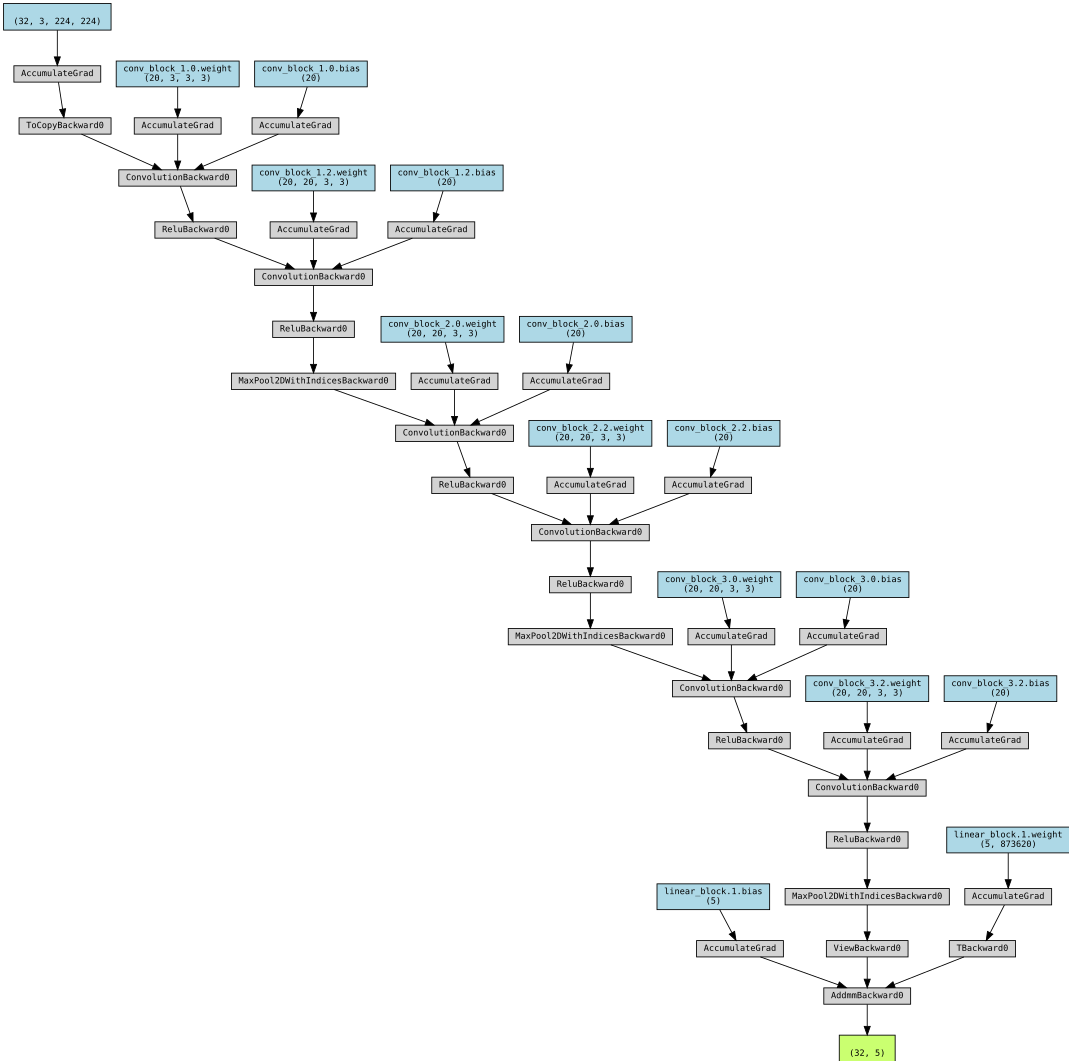

In [70]:
dot

In [71]:
dot.render("model_graph_v0_5_label", format="png")

print("Model graph saved as model_graph.png")

Model graph saved as model_graph.png
